# `plot_bloch_multivector`

This notebook demonstrates how to visualize quantum states using Bloch sphere representations and density matrix "cityscape" plots.


## A Quick Refresher

A quantum state of an $n$-qubit system can be represented as:

- A **statevector**:
  $$
  |\psi\rangle = \sum_{i=0}^{2^n -1} \alpha_i |i\rangle
  $$

- Or a **density matrix**:
  $$
  \rho = |\psi\rangle \langle \psi|
  $$

| Representation | Use case |
|------|--------|
| Statevector | Pure states, simulation |
| Density matrix | Mixed states, noise |

---


### Bloch Sphere Coordinates and Expectation Values

A general 1-qubit pure state can be written as:
$$
|\psi\rangle = \cos\frac{\theta}{2}\,|0\rangle + e^{i\phi}\sin\frac{\theta}{2}\,|1\rangle
$$

- $ \theta $: polar angle  
- $ \phi $: azimuthal angle  

The Bloch sphere represents the state using **expectation** values of Pauli operators:
$$
x = \langle X \rangle,\quad
y = \langle Y \rangle,\quad
z = \langle Z \rangle
$$

For any operator $O$, the expectation value is:

$$
\langle O \rangle = \langle \psi | O | \psi \rangle
$$

These expectation values are what get plotted in Bloch sphere visualizations.

For the state $\ket{\psi}$:
$$
x = \sin\theta \cos\phi,\quad
y = \sin\theta \sin\phi,\quad
z = \cos\theta
$$


$$
(\langle X \rangle, \langle Y \rangle, \langle Z \rangle)
= (\sin\theta\cos\phi,\; \sin\theta\sin\phi,\; \cos\theta)
$$

These are exactly the Cartesian coordinates of a point on the unit sphere.

#### Density Matrix Form

$$
\rho = \frac{1}{2}(I + xX + yY + zZ)
$$

So the Bloch vector $(x,y,z)$ fully characterizes a 1-qubit state


#### Multi-Qubit Case

For multi-qubit systems, we compute Bloch vectors **per qubit**:

$$
\langle I \otimes \dots \otimes P_i \otimes \dots \rangle
$$

$P \in \{X,Y,Z\}$

___

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit.visualization import plot_bloch_multivector, plot_state_city
import numpy as np

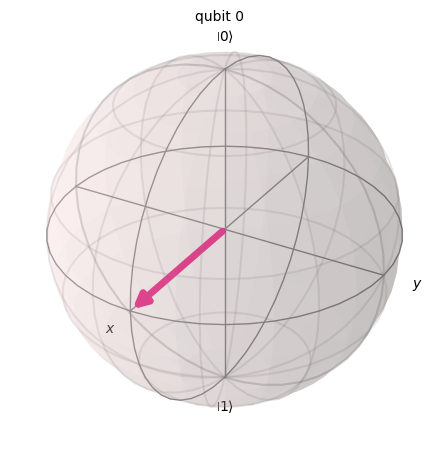

In [ ]:
qc = QuantumCircuit(1)
qc.h(0)  # creates |+> state

state = Statevector(qc)
plot_bloch_multivector(state) # plus state is a +1 eigenstate of the X operator, so it points along the +X axis on the Bloch sphere.


### Bloch sphere representation for multi qubit states

For a multi-qubit system, the Bloch sphere visualization (`plot_bloch_multivector`) shows the state of **each qubit individually**, not the full system.

This is done using the **reduced density matrix**:

$$
\rho_i = \text{Tr}_{\bar{i}}(\rho)
$$

and plotting:
$$
(\langle X_i \rangle,\; \langle Y_i \rangle,\; \langle Z_i \rangle)
$$


Consider a 2-qubit state:
$$
|\psi\rangle = \alpha |00\rangle + \beta |11\rangle
$$

- If $ |\alpha| = |\beta| $ → **maximally entangled (Bell state)**  
- If one dominates → **weakly entangled / nearly separable**


The reduced density matrix of one qubit is:
$$
\rho_1 =
|\alpha|^2 |0\rangle\langle 0| + |\beta|^2 |1\rangle\langle 1|
$$

This is a **mixed state**.



From this:
$$
x = 0,\quad y = 0,\quad z = |\alpha|^2 - |\beta|^2
$$

*Bloch vector lies along the **Z-axis***



- Length of Bloch vector:
  $$
  |\vec{r}| = |\,|\alpha|^2 - |\beta|^2\,|
  $$


- $|\vec{r}| = 1$  
  → Reduced state is pure → no entanglement in full state (product state)

- $0 < |\vec{r}| < 1$  
  → Reduced state is mixed → partial entanglement in full state 

- $|\vec{r}| = 0$  
  → Reduced state maximally mixed → maximal entanglement in full state 

- More entanglement → Bloch vector shrinks toward center  
- Less entanglement → Bloch vector moves toward surface  

____

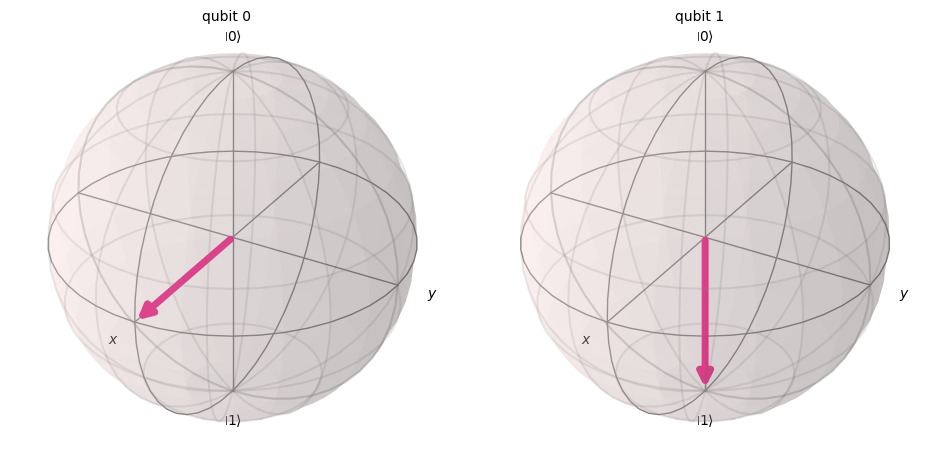

In [ ]:
# Two-Qubit System

qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)

state = Statevector(qc)
plot_bloch_multivector(state) # the two qubits are unentangled hence can be represented as separate points on the surface of the Bloch sphere.

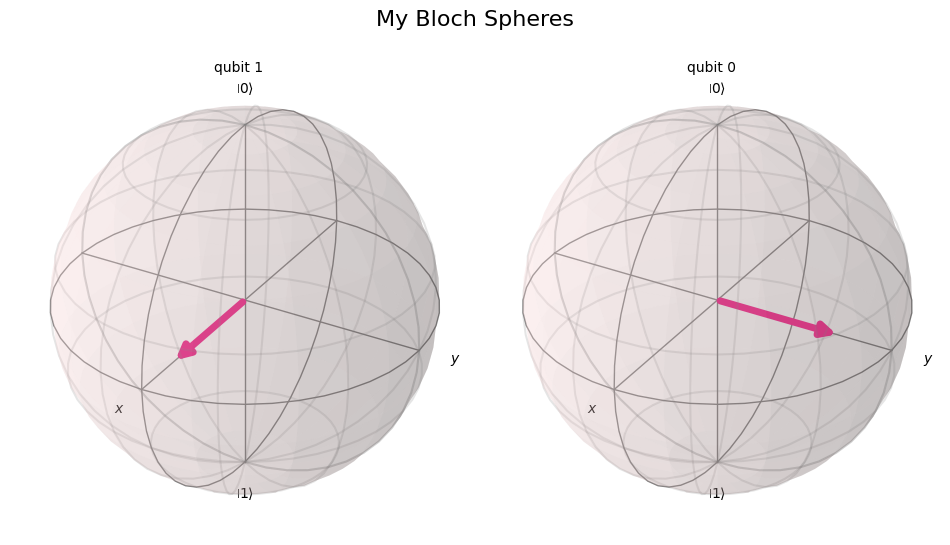

In [18]:
# You can reverse the order of the qubits
# you can provide title and pass matrix 


qc = QuantumCircuit(2)
qc.h([0, 1])
qc.t(1)
qc.s(0)
qc.cx(0,1)

matrix = DensityMatrix(qc)
plot_bloch_multivector(matrix, title='My Bloch Spheres', reverse_bits=True) # the reduced state of each qubit is a mixed state, so they are represented as points inside the Bloch sphere. 

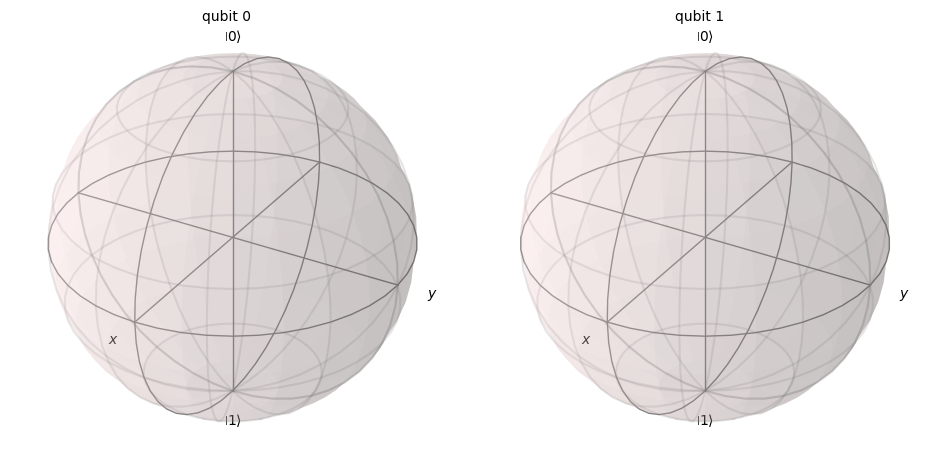

In [19]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

state = Statevector(qc)
plot_bloch_multivector(state) # the two qubits are maximally entangled

#### Why Bell states do not seem to show on the Bloch sphere ?


For the Bell state:
$$
|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)
$$

The reduced state of each qubit is:
$$
\rho_i = \frac{I}{2}
$$

This gives:
$$
\langle X \rangle = \langle Y \rangle = \langle Z \rangle = 0
$$

So the Bloch vector is:
$$
(0,0,0)
$$

This corresponds to the **center of the Bloch sphere**, meaning no visible vector.

___

### Density matrix visualization ("City Plot")

The density matrix:

$$
\rho_{ij} = \alpha_i \alpha_j^*
$$

- Diagonal → probabilities
- Off-diagonal → coherence

This is visualized using 3D bars.

Density Matrix
[[0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]]


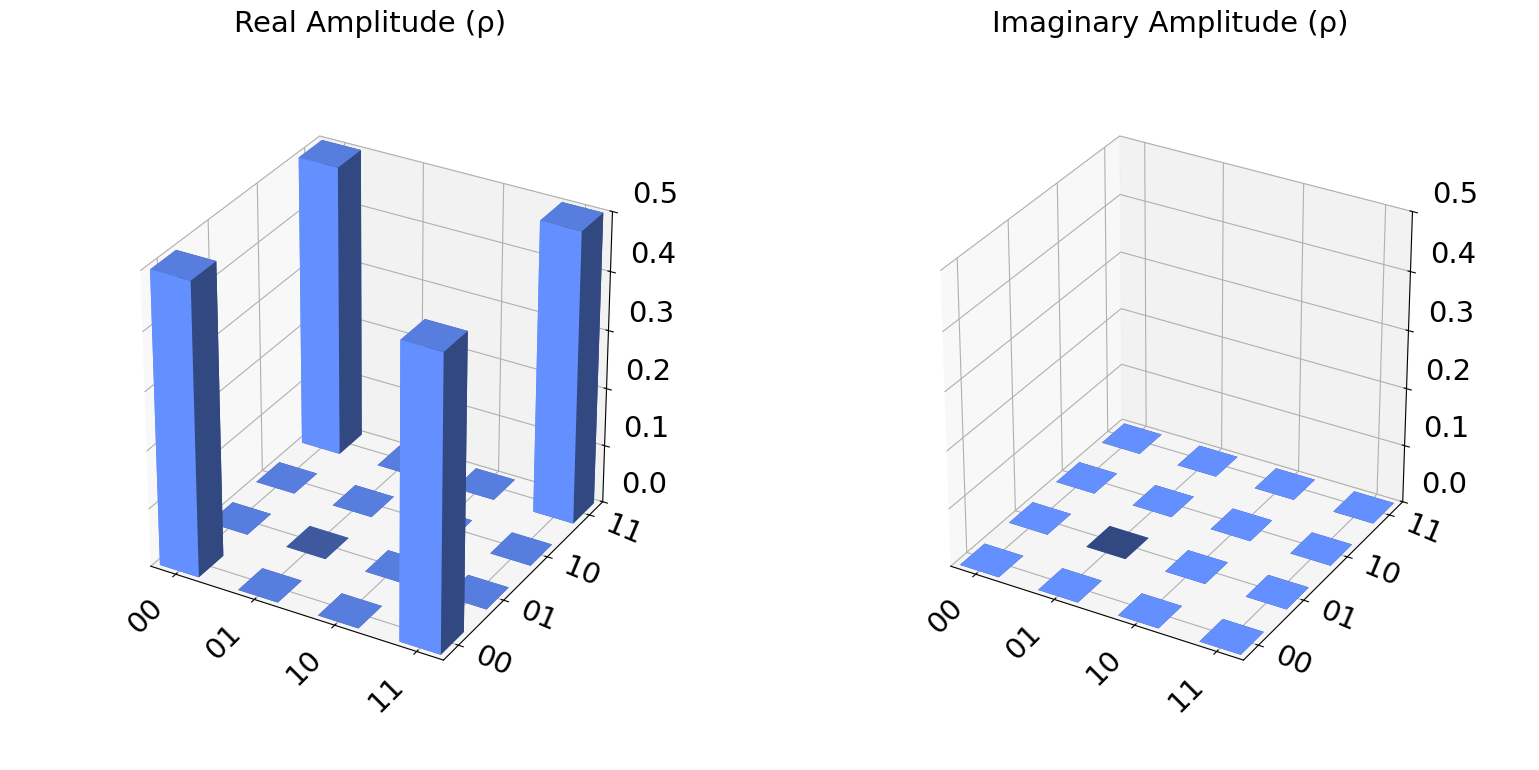

In [13]:
rho = DensityMatrix(qc)

print("Density Matrix")
print(rho.data) # this will show the density matrix of the state

plot_state_city(rho)

### How to Read the City Plot

- **Diagonal bars** → probabilities of individual states in the superposition
- **Off-diagonal bars** → quantum coherence
- **Imaginary components** → phase information

#### Note:

- No off-diagonal terms → classical mixture
- Strong off-diagonal terms → quantum superposition

#### Arbitrary rotation (single qubit state)

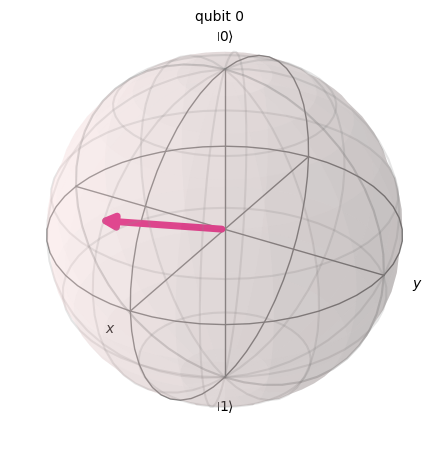

In [10]:
qc = QuantumCircuit(1)
qc.ry(np.pi/3, 0)
qc.rx(np.pi/5, 0)

state = Statevector(qc)
plot_bloch_multivector(state)

___
___